In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
from scipy.stats import norm

df_raw = pd.read_csv('a2142.dat')

z_obs = df_raw['z'].values

z_min = z_obs.min()
z_max = z_obs.max()

print(f"Letti {len(z_obs)} redshift.")
print(f"Range: da {z_min:.4f} a {z_max:.4f}")

# Puoi fare lo stesso anche con le altre colonne, ad esempio:
# dispersioni_velocita = df_raw['veldisp'].values

Letti 216 redshift.
Range: da 0.0306 a 0.4408


In [ ]:

def log_prior(theta):
    z0, sigma_z, f = theta
    if (z_min < z0 < z_max) and (0.0 < sigma_z < 0.1) and (0.0 <= f <= 1.0):
        return 0.0  
    return -np.inf  


def log_likelihood(theta, z, z_min, z_max):
    z0, sigma_z, f = theta
    
    prob_cluster = f * norm.pdf(z, loc=z0, scale=sigma_z)
    
    prob_field = (1.0 - f) / (z_max - z_min)
    
    # Probabilità totale per ogni galassia
    prob_totale = prob_cluster + prob_field
    
    return np.sum(np.log(prob_totale))


def log_probability(theta, z, z_min, z_max):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, z, z_min, z_max)

In [ ]:
# 1. Guess iniziale (punto di partenza per i camminatori)
z0_guess = np.median(z_obs)          # Mediana robusta agli outlier
sigma_z_guess = np.std(z_obs) / 4.0  # Assumiamo che l'ammasso sia uno spike stretto
f_guess = 0.5                        # Ipotizziamo a naso 50% cluster, 50% background

initial_guess = [z0_guess, sigma_z_guess, f_guess]

# 2. Impostazione dei camminatori
nwalkers = 32
ndim = 3
# Creiamo una piccola nuvola di punti attorno al guess iniziale
pos = initial_guess + 1e-4 * np.random.randn(nwalkers, ndim)

# 3. Lancio di Emcee
print("Avvio MCMC...")
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(z_obs, z_min, z_max))
# Facciamo fare 5000 passi a ogni camminatore
sampler.run_mcmc(pos, 5000, progress=True)
print("MCMC Completato!")

Avvio MCMC...


100%|██████████| 5000/5000 [00:09<00:00, 536.08it/s]

MCMC Completato!


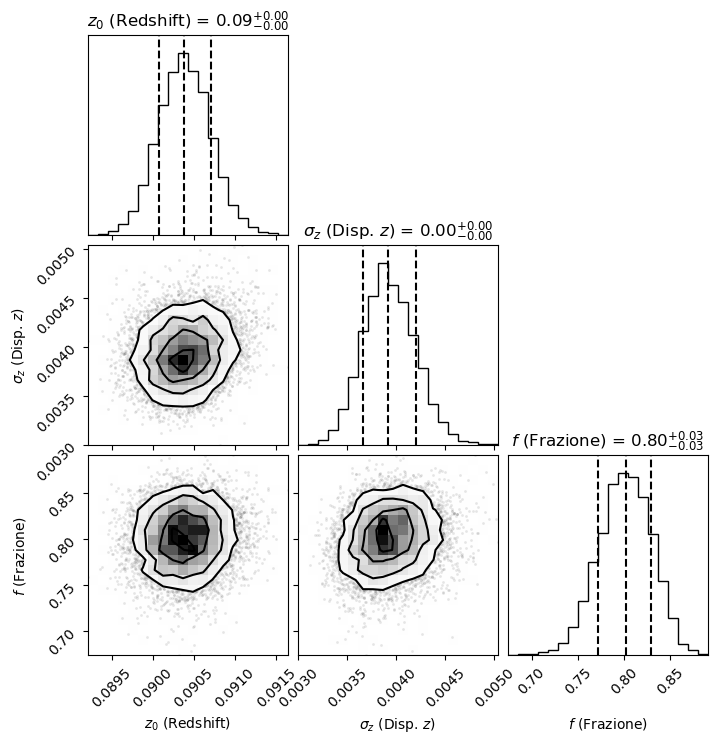

--- RISULTATI DELL'INFERENZA ---
Redshift dell'ammasso (z0): 0.09038
Dispersione redshift (σ_z): 0.00392
Frazione del cluster (f)  : 80.2%


In [11]:
# Rimuoviamo i primi 1000 step ("burn-in") durante i quali l'algoritmo stava ancora cercando la zona giusta
# e "assottigliamo" la catena prendendo un campione ogni 15 per evitare autocorrelazione
flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True)

# Crea il corner plot
labels = [r"$z_0$ (Redshift)", r"$\sigma_z$ (Disp. $z$)", r"$f$ (Frazione)"]
fig = corner.corner(
    flat_samples, 
    labels=labels, 
    quantiles=[0.16, 0.5, 0.84], # Mostra la mediana e gli errori al 68% (1-sigma)
    show_titles=True, 
    title_kwargs={"fontsize": 12}
)
plt.show()

# Estrazione dei valori mediani
z0_mcmc, sigma_z_mcmc, f_mcmc = np.percentile(flat_samples, 50, axis=0)

print(f"--- RISULTATI DELL'INFERENZA ---")
print(f"Redshift dell'ammasso (z0): {z0_mcmc:.5f}")
print(f"Dispersione redshift (σ_z): {sigma_z_mcmc:.5f}")
print(f"Frazione del cluster (f)  : {f_mcmc*100:.1f}%")

In [13]:
# Usiamo i valori mediani estratti dal fit Bayesiano (cella precedente)
# z0_mcmc, sigma_z_mcmc, f_mcmc

# 1. Calcoliamo la probabilità per ogni singola galassia del dataset
prob_cluster = f_mcmc * norm.pdf(z_obs, loc=z0_mcmc, scale=sigma_z_mcmc)
prob_field = (1.0 - f_mcmc) / (z_max - z_min)
prob_totale = prob_cluster + prob_field

# 2. Calcoliamo la "Responsibility" (Probabilità di appartenenza all'ammasso)
# È il rapporto tra la probabilità di essere nel cluster e la probabilità totale
p_membership = prob_cluster / prob_totale

# 3. Aggiungiamo queste informazioni al DataFrame originale
df_raw['p_cluster'] = p_membership

# Consideriamo membro dell'ammasso una galassia con oltre il 50% di probabilità
# Puoi alzare questa soglia (es. 0.8) se vuoi un campione ancora più puro
soglia = 3*sigma_z_mcmc
df_raw['is_member'] = df_raw['p_cluster'] > soglia

# 4. CREIAMO IL DATASET PULITO
# Filtriamo tenendo SOLO le galassie che appartengono alla Gaussiana
df_cluster = df_raw[df_raw['is_member']].copy()

# Stampiamo il resoconto
galassie_totali = len(df_raw)
galassie_ammasso = len(df_cluster)
galassie_scartate = galassie_totali - galassie_ammasso

print(f"--- FILTRAGGIO COMPLETATO ---")
print(f"Galassie totali iniziali : {galassie_totali}")
print(f"Galassie dell'ammasso    : {galassie_ammasso}")
print(f"Galassie di background scartate: {galassie_scartate}")

# Ora df_cluster è il tuo nuovo dataset. 
# Ad esempio, per calcolare la dispersione o le masse viriali sommerai su questo:
# display(df_cluster.head())

--- FILTRAGGIO COMPLETATO ---
Galassie totali iniziali : 216
Galassie dell'ammasso    : 179
Galassie di background scartate: 37


In [ ]:
D=z0_mcmc*3e5/70
print(f"Distanza comovente stimata: {D:.2f} Mpc")

disp_vel = df_raw['veldisp'].values

Distanza comovente stimata: 387.35 Mpc
